In [48]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [49]:
load_dotenv()

True

In [50]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.1)

In [51]:
class LLmState(TypedDict):
    question:str
    answer:str

In [52]:
graph = StateGraph(LLmState)

In [53]:
def chat(state:LLmState) -> LLmState:
    question = state["question"]
    prompt = f"Answer the following question: {question}"
    answer = model.invoke(prompt)
    state["answer"] = answer.content
    return state

    


In [54]:
# add nodes
graph.add_node("chat", chat)

In [55]:
# add edges
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

In [56]:
# compile the graph
# graph.compile()
workflow = graph.compile()



In [57]:
# Execute the workflow
initial_state = {"question": "What is the capital of France?"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is **Paris**.'}


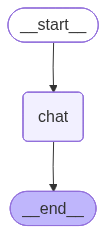

In [58]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

**Prompt Chaining Workflow**


In [59]:
class llm_state(TypedDict):
    title:str
    outline:str
    blog:str
    

In [60]:
# create graph for blog writing workflow
graph = StateGraph(llm_state)

In [61]:
def outline_gen(state:llm_state) -> llm_state:
    title = state['title']
    prompt = f"Generate a detailed outline for the title: {title}"
    outline = model.invoke(prompt)
    state['outline'] = outline.content
    return state


In [62]:
def blog_gen(state: llm_state) -> llm_state:
    title = state['title']
    outline = state['outline']
    prompt = f"Write a detailed blog post based on the following title and outline.\nTitle: {title}\nOutline: {outline}"
    blog = model.invoke(prompt)
    state['blog'] = blog.content
    return state


In [63]:
# add nodes
graph.add_node("outline_gen", outline_gen)
graph.add_node("blog_gen", blog_gen)

In [64]:
# add edges
graph.add_edge(START, "outline_gen")
graph.add_edge("outline_gen", "blog_gen")   
graph.add_edge("blog_gen", END)


In [65]:
# comile the graph
workflow1 = graph.compile()


In [66]:
# execute the graph
initial_state = {'title': "Consequences of Iran and America war"}
final_state = workflow1.invoke(initial_state)
print(final_state)


{'title': 'Consequences of Iran and America war', 'outline': "A war between Iran and the United States would be a conflict with profound, far-reaching, and catastrophic consequences, impacting not only the belligerents but also the entire Middle East and the global community. This outline details the potential ramifications across various domains.\n\n---\n\n**Detailed Outline: Consequences of Iran and America War**\n\n**I. Introduction**\n    A. Historical Context of Iran-US Tensions\n        1. Decades of animosity, mistrust, and proxy conflicts\n        2. Key flashpoints: 1979 Revolution, hostage crisis, nuclear program, sanctions, regional proxy wars\n    B. Nature of a Potential Conflict\n        1. Unlikely to be a conventional ground invasion initially; more likely air, naval, cyber, and special operations\n        2. High potential for rapid escalation and regional spillover\n    C. Thesis Statement: A war between Iran and the United States would unleash a cascade of devastatin

In [68]:
print(final_state['outline'])

A war between Iran and the United States would be a conflict with profound, far-reaching, and catastrophic consequences, impacting not only the belligerents but also the entire Middle East and the global community. This outline details the potential ramifications across various domains.

---

**Detailed Outline: Consequences of Iran and America War**

**I. Introduction**
    A. Historical Context of Iran-US Tensions
        1. Decades of animosity, mistrust, and proxy conflicts
        2. Key flashpoints: 1979 Revolution, hostage crisis, nuclear program, sanctions, regional proxy wars
    B. Nature of a Potential Conflict
        1. Unlikely to be a conventional ground invasion initially; more likely air, naval, cyber, and special operations
        2. High potential for rapid escalation and regional spillover
    C. Thesis Statement: A war between Iran and the United States would unleash a cascade of devastating human, economic, political, social, and environmental consequences, desta

In [69]:
print(final_state['blog'])

## The Unthinkable Cost: Unpacking the Catastrophic Consequences of an Iran-America War

The specter of a direct military conflict between Iran and the United States has loomed large over the Middle East for decades. While often discussed in hypothetical terms, the reality of such a confrontation would be a conflict with profound, far-reaching, and catastrophic consequences, impacting not only the belligerents but also the entire Middle East and the global community. It's a scenario that demands careful consideration, not to sensationalize, but to underscore the imperative of de-escalation and diplomacy.

### I. Introduction: A Powder Keg Decades in the Making

The relationship between Iran and the United States is a tapestry woven with decades of animosity, mistrust, and proxy conflicts. From the seismic shift of the 1979 Islamic Revolution and the subsequent hostage crisis, through the complexities of Iran's nuclear program, crippling sanctions, and a web of regional proxy wars, each

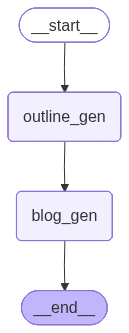

In [67]:
# visualize the graph
Image(workflow1.get_graph().draw_mermaid_png())